# 🎓 Student Placement Prediction — Advanced Classification Portfolio Project

---

| Field | Details |
|---|---|
| **Dataset** | Campus Recruitment dataset — `Placement_Data_Full_Class.csv` (Kaggle) |
| **Type** | Supervised Learning · Binary Classification |
| **Level** | Advanced · Portfolio Grade |
| **Models** | Logistic Regression · KNN · Naive Bayes · SVM · Random Forest · Gradient Boosting |
| **Advanced** | ROC-AUC · Precision-Recall Curves · SMOTE · class_weight · GridSearchCV · Learning Curves · Probability Calibration · Feature Importance |

---

## 📌 Project Objective

Predict whether a student will be **placed (hired)** or **not placed** based on academic records and test scores.

This is a **binary classification** problem with real-world stakes:
- A college wants to identify **at-risk students** early and provide targeted support
- An accurate model can guide resource allocation for placement training

**Kaggle dataset challenges:**
- Real data with missing values and mixed data types
- Moderate class imbalance
- Categorical features requiring encoding
- Feature selection from a meaningful but limited feature set


## Section 01

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

from scipy import stats

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, learning_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report, average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# SMOTE for Class imbalance

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
    print("Imbalanced-learn available")

except ImportError:
    SMOTE_AVAILABLE = False
    print("imbalanced-learn not installed.")

RANDOM_STATE = 42

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')
print('All Library Loaded. Lets get started...')


Imbalanced-learn available
All Library Loaded. Lets get started...


## Section 2 - Data Loading 

**Dataset:** Download `Placement_Data_Full_Class.csv` from
[Kaggle — Campus Recruitment](https://www.kaggle.com/benroshan/factors-affecting-campus-placement)

| Column | Description |
|---|---|
| `sl_no` | Serial number (drop — not a feature) |
| `gender` | Male / Female |
| `ssc_p` | Secondary school % (10th grade) |
| `ssc_b` | Secondary school board (Central / Others) |
| `hsc_p` | Higher secondary % (12th grade) |
| `hsc_b` | Higher secondary board |
| `hsc_s` | Higher secondary stream (Science/Commerce/Arts) |
| `degree_p` | Degree percentage |
| `degree_t` | Degree type |
| `workex` | Work experience (Yes/No) |
| `etest_p` | Employability test percentage |
| `specialisation` | MBA specialisation (Mkt&HR / Mkt&Fin) |
| `mba_p` | MBA percentage |
| `status` | **Target** — Placed / Not Placed |
| `salary` | Salary offered (only if placed — we will drop this to avoid leakage) |

In [2]:
df = pd.read_csv('Data\Placement_Data_Full_Class.csv')

print(f"Dataset Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nTarget Distribution: ")
print(df['status'].value_counts())
print(f"\nPlacement Rate: {(df["status"] == "Placed").mean()*100:.1f}%")

df.head()


Dataset Loaded: 215 rows x 15 columns

Columns: ['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status', 'salary']

Target Distribution: 
status
Placed        148
Not Placed     67
Name: count, dtype: int64

Placement Rate: 68.8%


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


## Section 3 - Exploratory Data Analysis (EDA)

In [3]:
# 3.1 Overview

print("Missing Values: ")
print(df.isnull().sum())
print(f"\n Salary is missing for {df['salary'].isnull().sum()} records, which is expected for 'Not Placed' students.")
print("\nData Types: ")
print(df.dtypes)

Missing Values: 
sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

 Salary is missing for 67 records, which is expected for 'Not Placed' students.

Data Types: 
sl_no               int64
gender                str
ssc_p             float64
ssc_b                 str
hsc_p             float64
hsc_b                 str
hsc_s                 str
degree_p          float64
degree_t              str
workex                str
etest_p           float64
specialisation        str
mba_p             float64
status                str
salary            float64
dtype: object


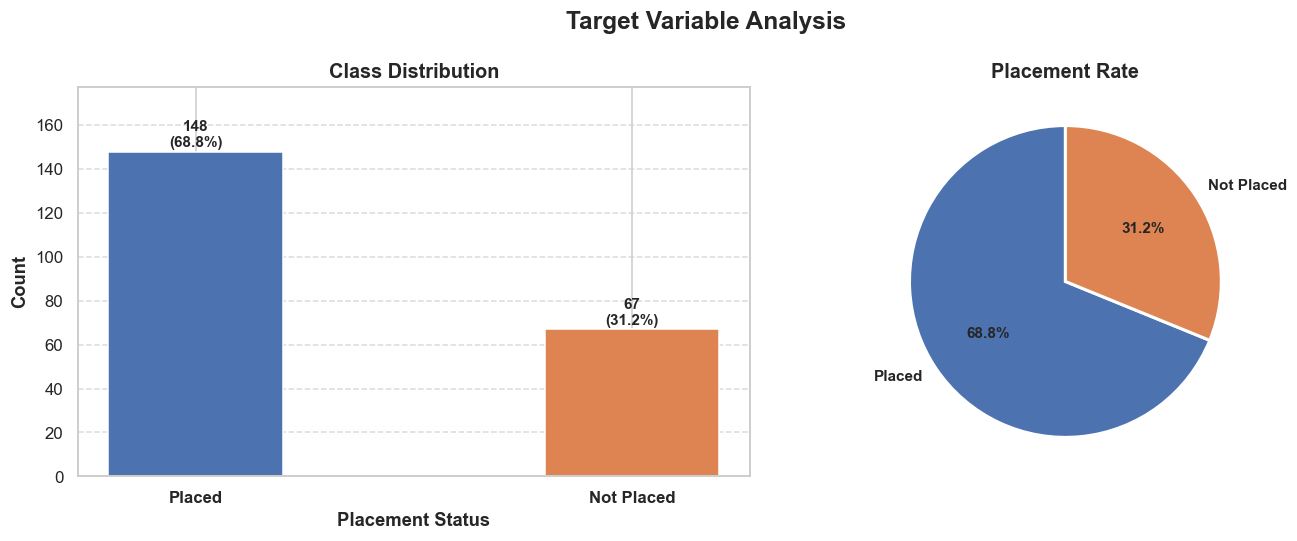

Imbalance Ratio: 2.21 (Not Placed : Placed)
Class imbalance is moderate. Standard modeling techniques may perform adequately, but always evaluate with appropriate metrics.


In [4]:
# 3.2 Class Distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['status'].value_counts()
colors = ['#4c72b0', '#dd8452']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.4)

for i, (label, v) in enumerate(counts.items()):
    axes[0].text(i, v+2, f"{v}\n({v/len(df)*100:.1f}%)", ha='center', fontsize=10, fontweight='bold')

axes[0].set_title("Class Distribution", fontweight='bold', fontsize=13)
axes[0].set_ylabel("Count", fontweight='bold')
axes[0].set_xlabel("Placement Status", fontweight='bold')
axes[0].set_ylim(0, counts.max()*1.2)
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(counts.index, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Pie Chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Placement Rate", fontweight='bold', fontsize=13)

plt.suptitle("Target Variable Analysis", fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f"Imbalance Ratio: {imbalance_ratio:.2f} (Not Placed : Placed)")
if imbalance_ratio > 3:
    print("Warning: Significant class imbalance detected. Consider using techniques like SMOTE or class weighting during model training.")
else:
    print("Class imbalance is moderate. Standard modeling techniques may perform adequately, but always evaluate with appropriate metrics.")

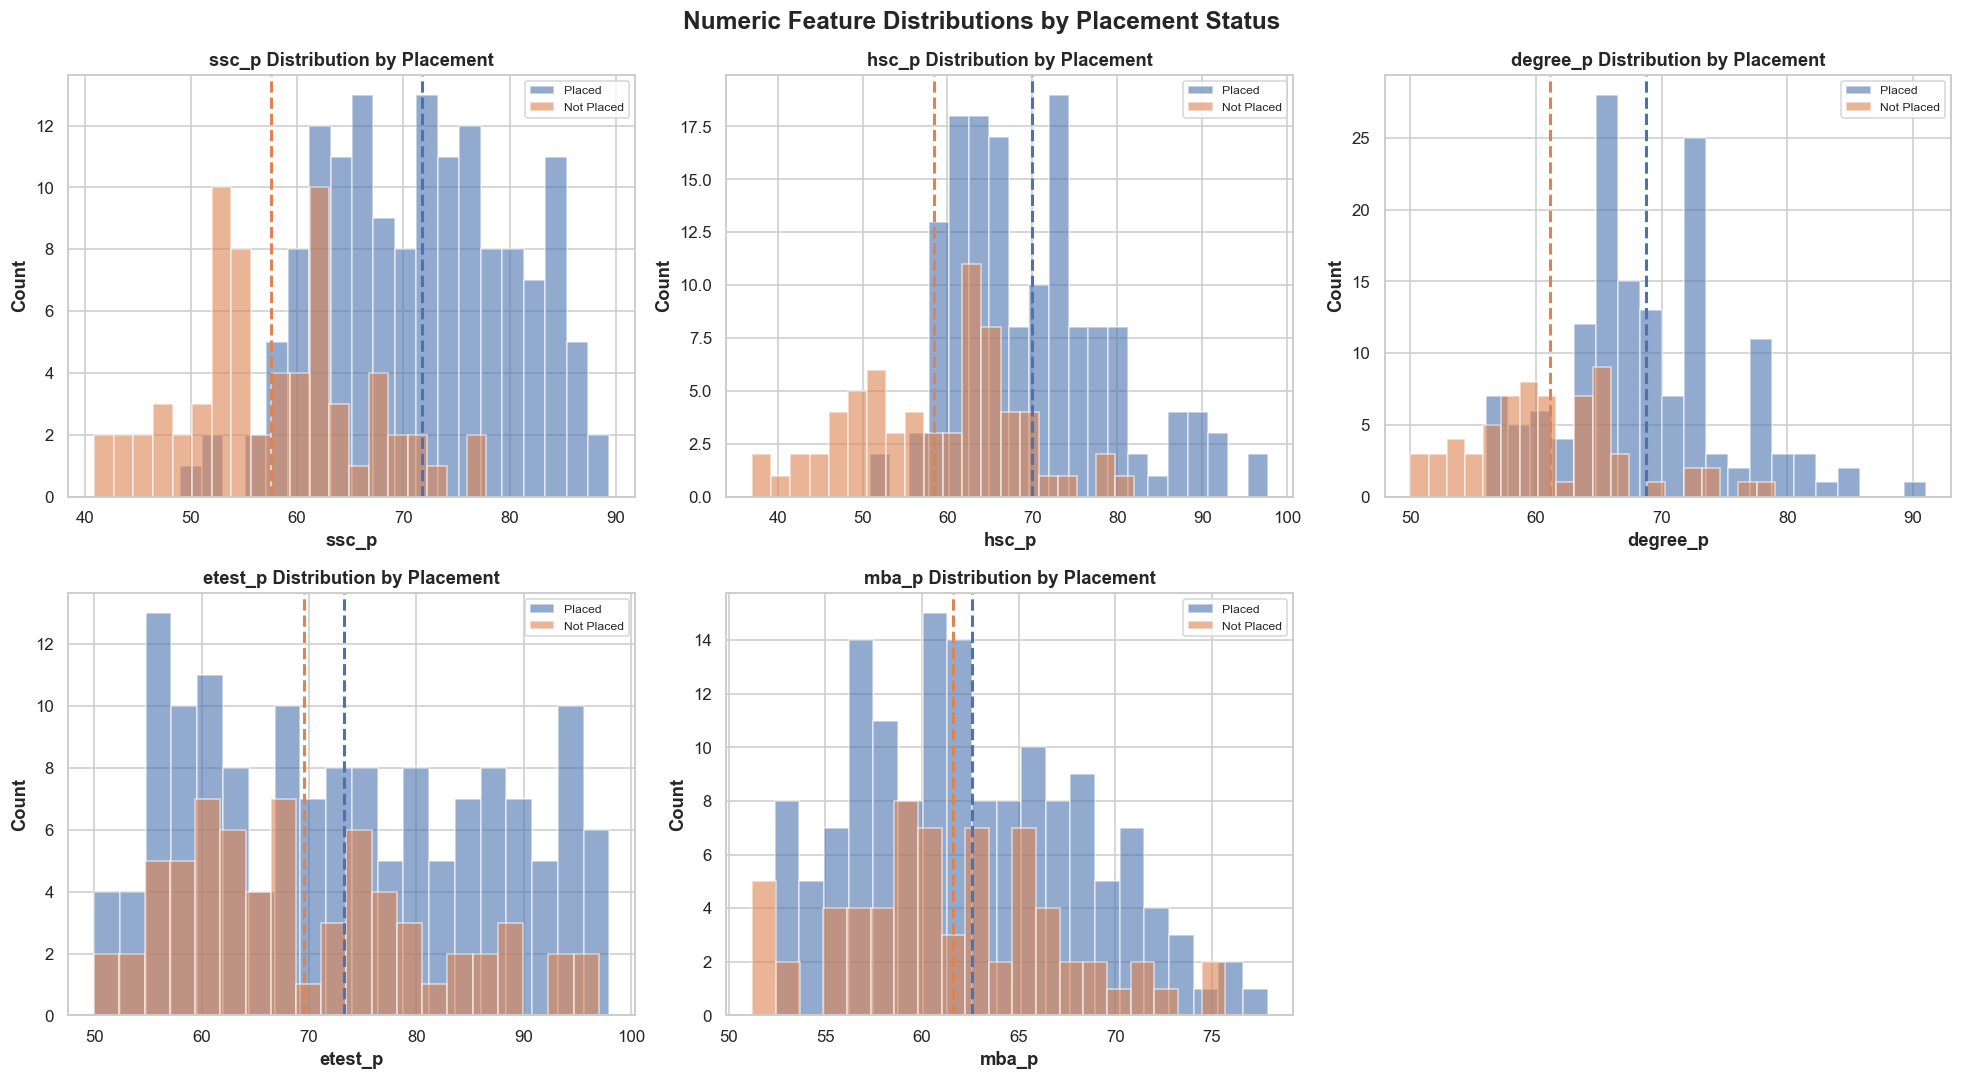

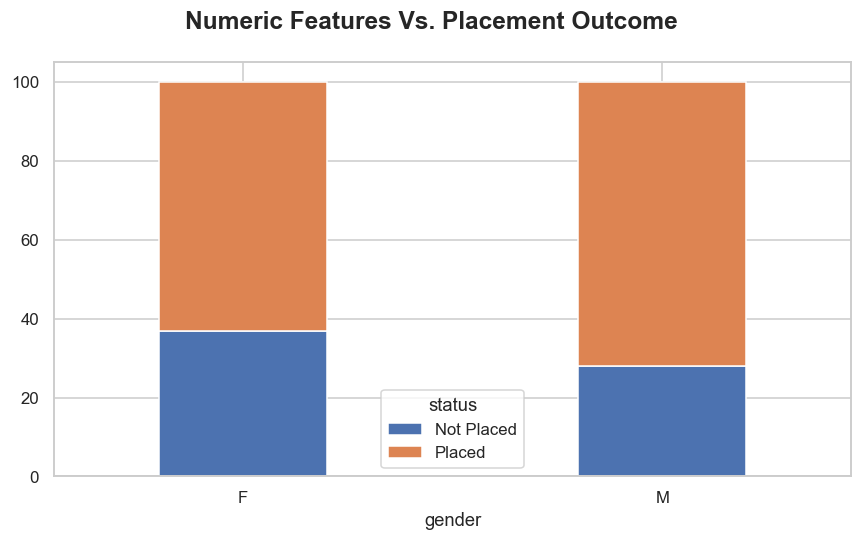

In [5]:
# 3.3 Numeric feature Distribution by Placement

num_feats = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
palette = {'Placed': '#4c72b0', 'Not Placed': '#dd8452'}

for i, feat in enumerate(num_feats):
    for label, color in palette.items():
        subset = df[df['status'] == label][feat]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
        axes[i].axvline(subset.mean(), color=color, linestyle='dashed', linewidth=2)
    axes[i].set_title(f"{feat} Distribution by Placement", fontweight='bold')
    axes[i].set_xlabel(feat, fontweight='bold')
    axes[i].set_ylabel("Count", fontweight='bold')
    axes[i].legend(fontsize=8)
axes[-1].axis('off')
plt.suptitle("Numeric Feature Distributions by Placement Status", fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

# Placement by gender

gender_cross = pd.crosstab(df['gender'], df['status'], normalize='index') * 100
gender_cross.plot(kind='bar', stacked=True, color=colors, edgecolor='white', figsize=(8, 5), width=0.4, rot=0)
axes[5].set_title("Placement by Gender", fontweight="bold")
axes[5].legend(title="Placement Status", fontsize=8)

plt.suptitle("Numeric Features Vs. Placement Outcome", fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

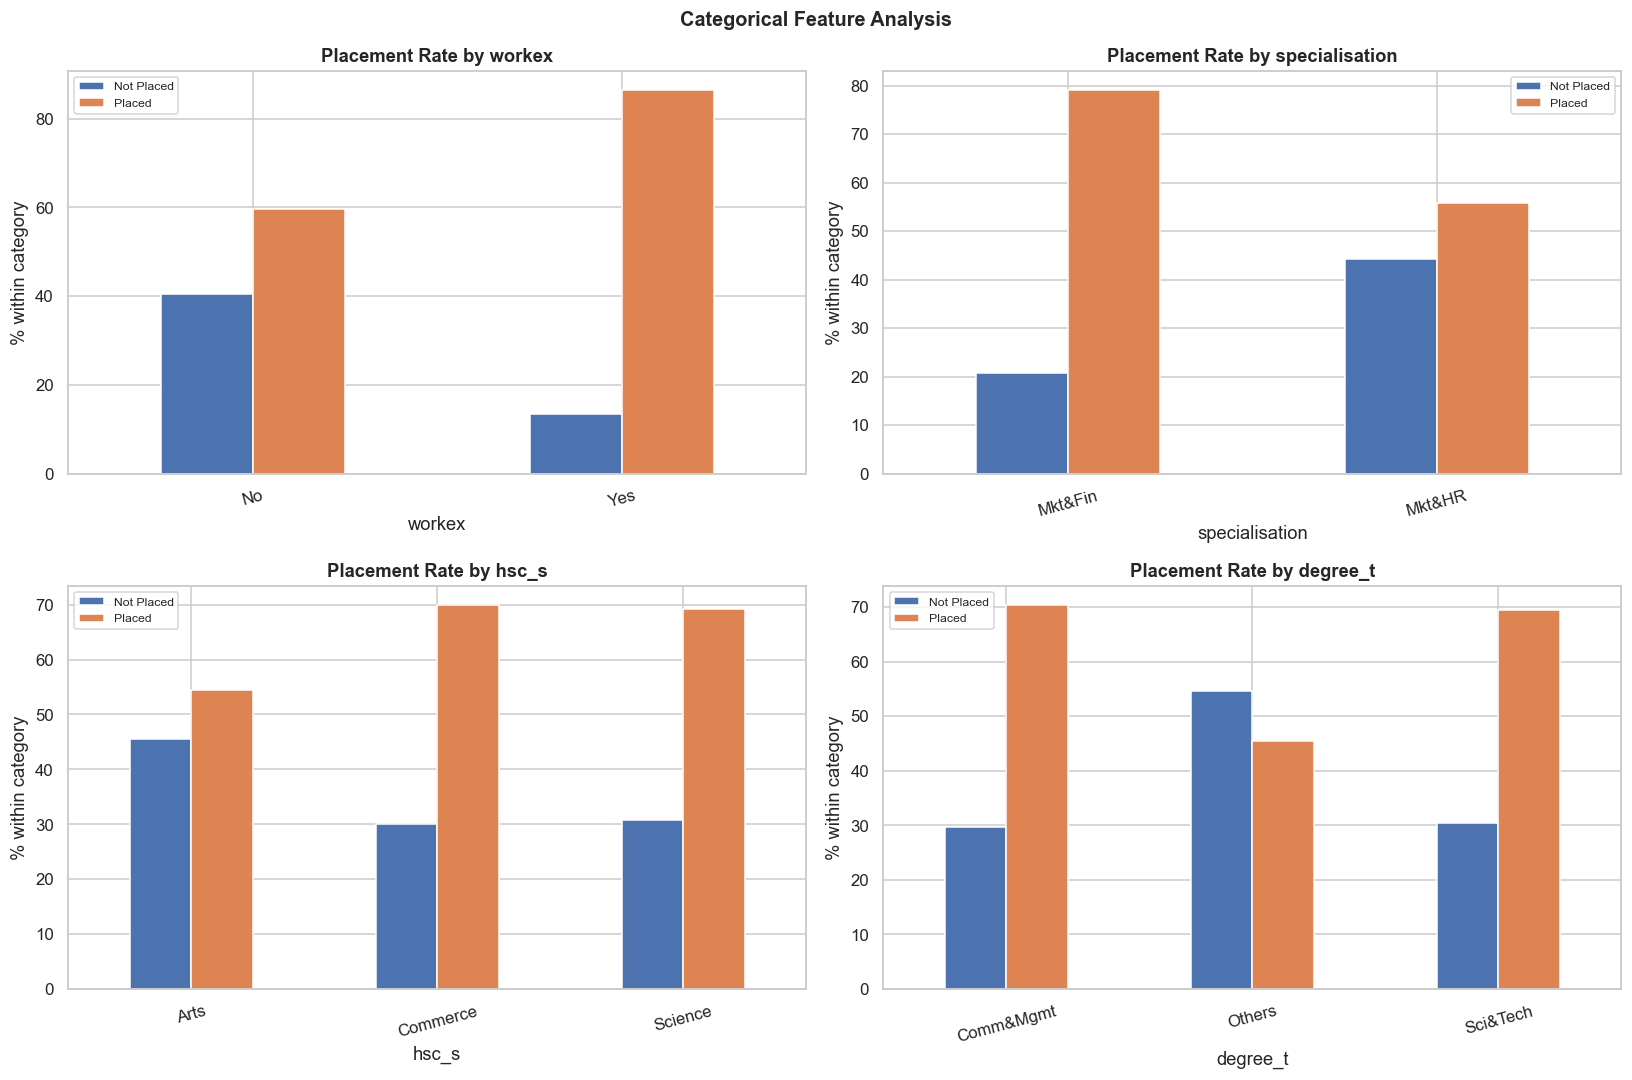

In [6]:
# 3.4 Categorical Features Vs. Placement

cat_feats = ['workex','specialisation','hsc_s','degree_t']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, feat in zip(axes.flatten(), cat_feats):
    ct = pd.crosstab(df[feat], df['status'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=colors, edgecolor='white', rot=15)
    ax.set_title(f'Placement Rate by {feat}', fontweight='bold')
    ax.set_ylabel('% within category')
    ax.legend(fontsize=8)

plt.suptitle('Categorical Feature Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


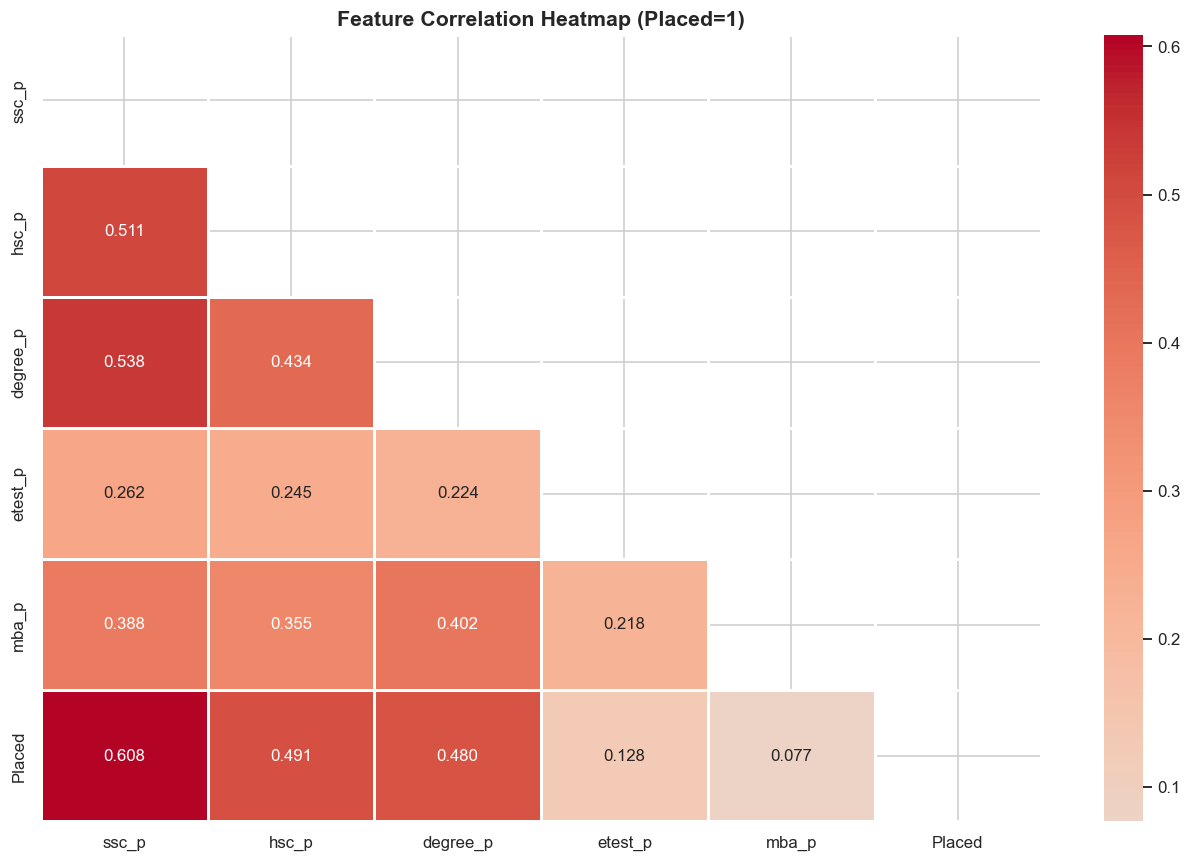

Correlation with Placement outcome:
ssc_p       0.607889
hsc_p       0.491228
degree_p    0.479861
etest_p     0.127639
mba_p       0.076922


In [7]:
# 3.5 Correlation Analysis

fig, ax = plt.subplots(figsize=(12, 8))
numeric_df = df[num_feats + ['status']].copy()
numeric_df['Placed'] = (numeric_df['status'] == 'Placed').astype(int)
numeric_df = numeric_df.drop(columns='status')

corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.8, ax=ax, annot_kws={'size':11})
ax.set_title('Feature Correlation Heatmap (Placed=1)', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

print('Correlation with Placement outcome:')
print(corr['Placed'].drop('Placed').sort_values(ascending=False).to_string())

## Section 4 - Data Preprocessing



### Key Steps
1. Drop `sl_no` (just a row number) and `salary` (**data leakage** — salary only exists if placed)
2. Encode categorical features
3. Stratified train-test split
4. StandardScaler (fit on train only)

### Why Drop Salary?
`salary` is only filled for students who were **placed**. It is 100% correlated with the target — if salary is present, status=Placed. Including it would give the model a perfect cheat code, resulting in 100% accuracy that tells us nothing. This is called **data leakage**.


In [8]:
# 4.1 Drop Leakage Columns

df_clean = df.drop(columns=['sl_no', 'salary'])
print(f"Shape after dropping leakage columns: {df_clean.shape}")

Shape after dropping leakage columns: (215, 13)


In [9]:
# 4.2 Encode Categorical Features

cat_cols = df_clean.select_dtypes(include='object').columns.drop('status')
print(f"Categorical columns to encode: {list(cat_cols)}")

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    le_dict[col]  = le


Categorical columns to encode: ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation']


In [10]:
# 4.3 Encode Target Variable

df_clean["Placed"] = (df_clean['status'] == 'Placed').astype(int)
df_clean = df_clean.drop(columns='status')

x = df_clean.drop(columns='Placed')
y = df_clean['Placed']

print(f"Final feature set shape: {x.shape}")
print(f"Target Distribution: Placed={y.sum()} ({y.mean()*100:.1f}%), Not Placed={len(y) - y.sum()} ({(1-y.mean())*100:.1f}%)")

Final feature set shape: (215, 12)
Target Distribution: Placed=148 (68.8%), Not Placed=67 (31.2%)


In [11]:
# 4.4 Stratified Train-Test Split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


print(f'Train: {x_train.shape[0]} samples | Placed: {y_train.mean()*100:.1f}%')
print(f'Test : {x_test.shape[0]}  samples | Placed: {y_test.mean()*100:.1f}%')


Train: 172 samples | Placed: 68.6%
Test : 43  samples | Placed: 69.8%


In [12]:
# 4.5 StandardScaler

scaler         = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

print("\n Data preprocessing completed. Ready for modeling.")


 Data preprocessing completed. Ready for modeling.


In [13]:
# Diagnostics: quick checks before modeling
print('Train shape:', x_train.shape)
print('Feature uniques (train):')
print(x_train.nunique())
print('Nulls per column:')
print(x_train.isnull().sum())
print('Target distribution (train):')
print(y_train.value_counts(normalize=True))
print('Top low-variance features:')
print(x_train.var().sort_values().head(10))
print('Duplicates in train (rows):', x_train.duplicated().sum())

Train shape: (172, 12)
Feature uniques (train):
gender              2
ssc_p              91
ssc_b               2
hsc_p              83
hsc_b               2
hsc_s               3
degree_p           77
degree_t            3
workex              2
etest_p            90
specialisation      2
mba_p             165
dtype: int64
Nulls per column:
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
dtype: int64
Target distribution (train):
Placed
1    0.686047
0    0.313953
Name: proportion, dtype: float64
Top low-variance features:
gender              0.218788
hsc_b               0.233476
workex              0.236468
specialisation      0.248062
ssc_b               0.249286
hsc_s               0.328573
degree_t            0.773664
mba_p              35.861579
degree_p           53.814996
ssc_p             1

In [14]:
# Drop constant / near-constant features (threshold adjustable)
const_cols = [c for c in x_train.columns if x_train[c].nunique() <= 1]
near_const = [c for c in x_train.columns if x_train[c].nunique() / len(x_train) < 0.01]  # adjust threshold
drop_cols = sorted(set(const_cols + near_const))
print('Dropping columns:', drop_cols)
if drop_cols:
    x_train = x_train.drop(columns=drop_cols)
    x_test  = x_test.drop(columns=drop_cols)
    print('New train shape:', x_train.shape)
else:
    print('No constant/near-constant columns found.')

Dropping columns: []
No constant/near-constant columns found.


In [15]:
# Re-scale after removing columns
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)
print('Re-scaling complete. Shapes:', x_train_scaled.shape, x_test_scaled.shape)

Re-scaling complete. Shapes: (172, 12) (43, 12)


## Section 5 - Modeling and Evaluation

| # | Model | Key Strength |
|---|---|---|
| 1 | Logistic Regression | Interpretable baseline, probability output |
| 2 | KNN | Non-parametric, simple |
| 3 | Naive Bayes | Fast, probabilistic |
| 4 | SVM (RBF) | Powerful on high-dimensional data |
| 5 | Random Forest | Robust ensemble, feature importance |
| 6 | Gradient Boosting | Highest accuracy, handles complex patterns |

In [16]:
def evaluate_classifier(name, model, x_tr, x_te, y_tr, y_te):
    """Train model, compute full metric suite and return results dict."""
    model.fit(x_tr, y_tr)
    te_pred = model.predict(x_te)
    tr_pred = model.predict(x_tr)

    if hasattr(model, 'predict_proba'):
        te_prob = model.predict_proba(x_te)[:, 1]
    else:
        te_prob = model.decision_function(x_te)
        te_prob = (te_prob - te_prob.min()) / (te_prob.max() - te_prob.min())

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_f1 = cross_val_score(model, x_tr, y_tr, cv=skf, scoring='f1').mean()

    return {
        'Model'     : name,
        'Train Acc' : accuracy_score(y_tr, tr_pred),
        'Test Acc'  : accuracy_score(y_te, te_pred),
        'Precision' : precision_score(y_te, te_pred, zero_division=0),
        'Recall'    : recall_score(y_te, te_pred, zero_division=0),
        'F1 Score'  : f1_score(y_te, te_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_te, te_prob),
        'CV F1'     : cv_f1,
        '_model'    : model,
        '_te_prob'  : te_prob,
        '_te_pred'  : te_pred,
    }

results = []

In [17]:
# 5.1 Logistic Regression
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, C=1.0, solver='lbfgs')
results.append(evaluate_classifier("Logistic Regression", lr, x_train_scaled, x_test_scaled, y_train, y_test))

# 5.2 K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=7)
results.append(evaluate_classifier("K-Nearest Neighbors", knn, x_train_scaled, x_test_scaled, y_train, y_test))

# 5.3 Naive Bayes
nb = GaussianNB()
results.append(evaluate_classifier("Naive Bayes", nb, x_train_scaled, x_test_scaled, y_train, y_test))

# 5.4 Support Vector Machine
svm = SVC(random_state=RANDOM_STATE, probability=True, kernel='rbf', C=1.0)
results.append(evaluate_classifier("Support Vector Machine", svm, x_train_scaled, x_test_scaled, y_train, y_test))

# 5.5 Random Forest
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, max_depth=5, max_features='sqrt', class_weight='balanced')
results.append(evaluate_classifier("Random Forest", rf, x_train, x_test, y_train, y_test))

# 5.6 Gradient Boosting
gb = GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=200, learning_rate=0.05, max_depth=3)
results.append(evaluate_classifier("Gradient Boosting", gb, x_train, x_test, y_train, y_test))

# 5.7 Results Summary
results_df = pd.DataFrame(results).drop(columns=['_model', '_te_prob', '_te_pred'])
print("\nModel Evaluation Summary:")
print(results_df[['Model', 'Train Acc', 'Test Acc', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'CV F1']].to_string(index=False))



Model Evaluation Summary:
                 Model  Train Acc  Test Acc  Precision   Recall  F1 Score  ROC-AUC    CV F1
   Logistic Regression   0.901163  0.837209   0.925926 0.833333  0.877193 0.930769 0.903106
   K-Nearest Neighbors   0.866279  0.790698   0.818182 0.900000  0.857143 0.880769 0.872072
           Naive Bayes   0.843023  0.930233   0.935484 0.966667  0.950820 0.964103 0.862956
Support Vector Machine   0.947674  0.883721   0.931034 0.900000  0.915254 0.905128 0.901962
         Random Forest   0.982558  0.860465   0.875000 0.933333  0.903226 0.958974 0.883364
     Gradient Boosting   1.000000  0.837209   0.848485 0.933333  0.888889 0.920513 0.866180


## Section 6 - Compregensive Evaluation

### 6.1 Confusion Matrices

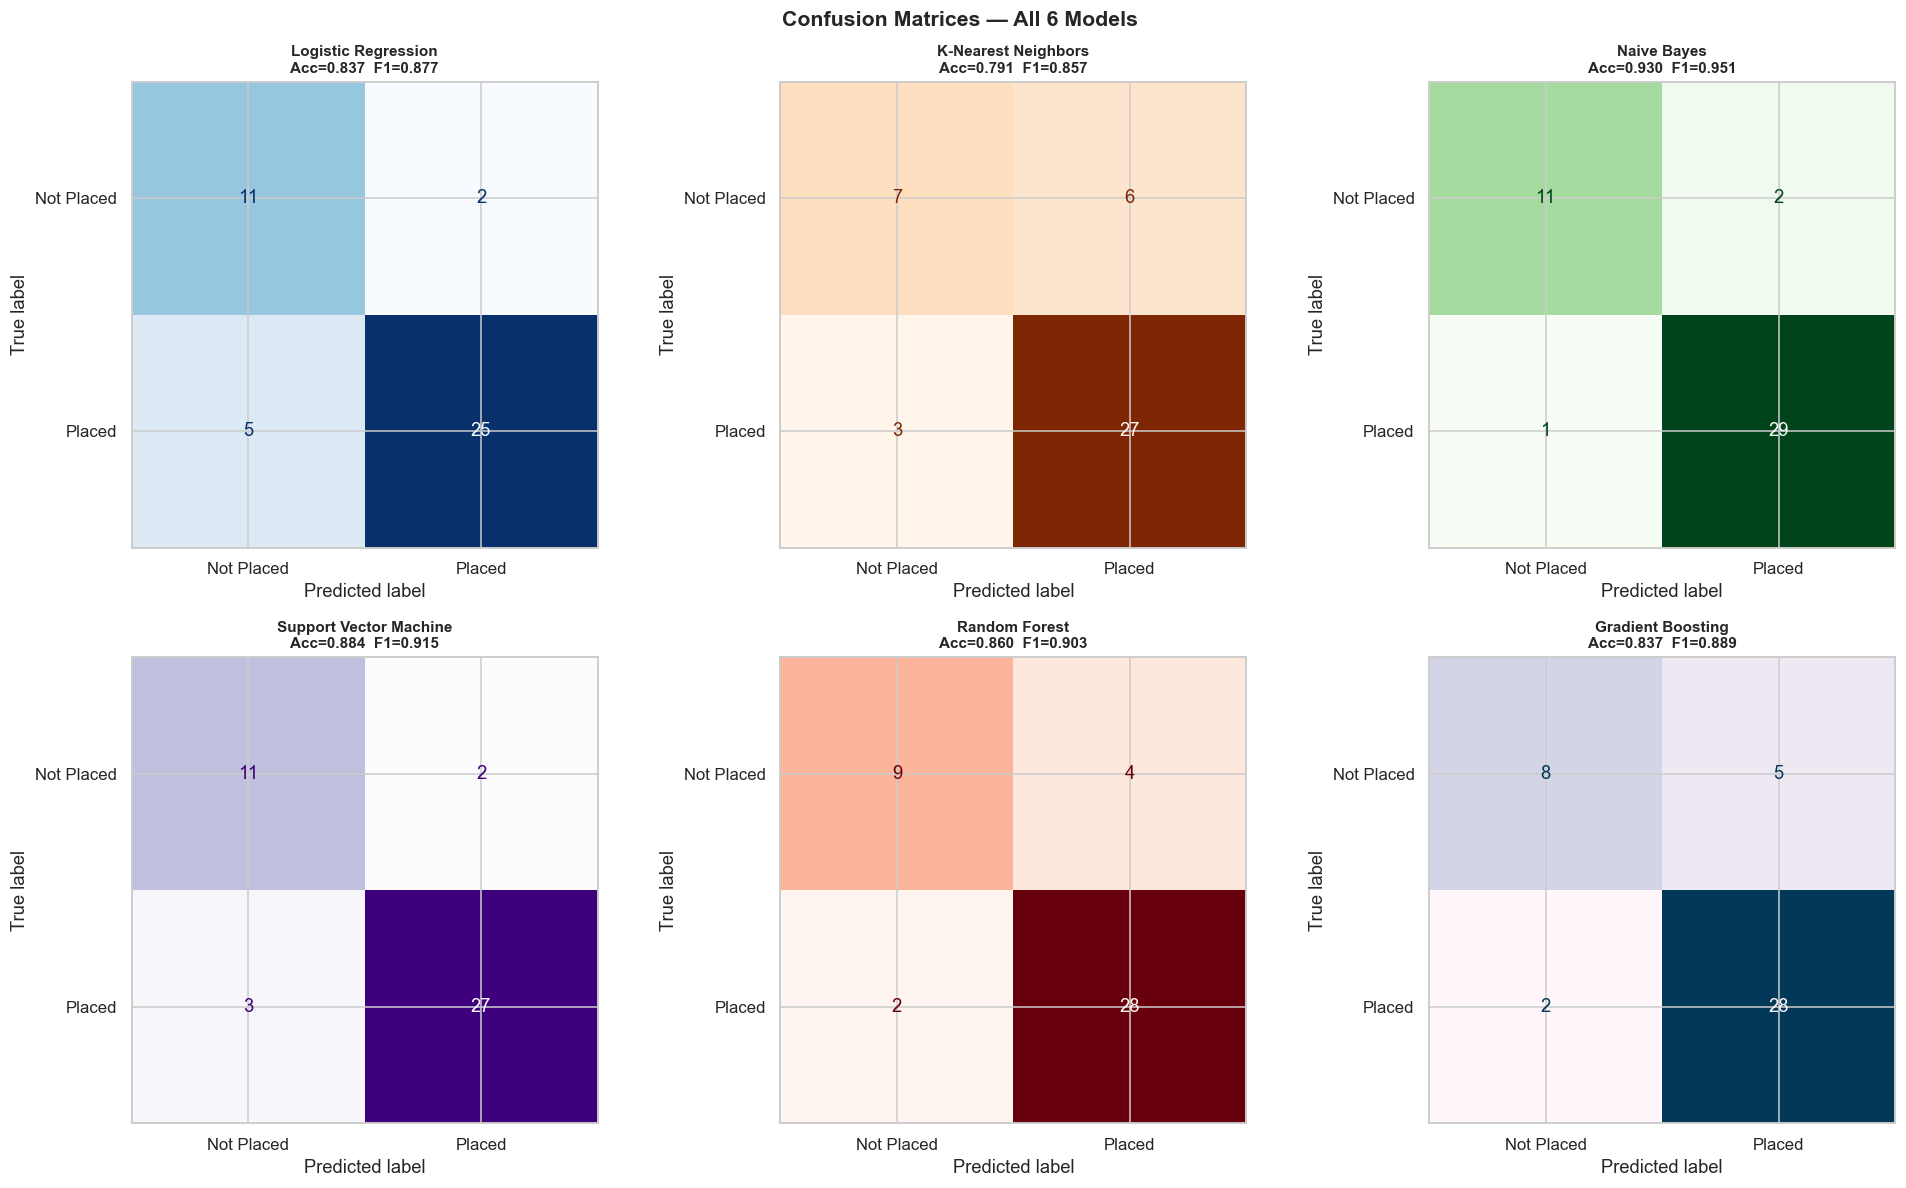

In [18]:
# 6.1 Confusion Matrices for All 6 Models ─
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
cmaps = ['Blues','Oranges','Greens','Purples','Reds','PuBu']

for ax, result, cmap in zip(axes.flatten(), results, cmaps):
    cm = confusion_matrix(y_test, result['_te_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Placed','Placed'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{result["Model"]}\nAcc={result["Test Acc"]:.3f}  F1={result["F1 Score"]:.3f}',
                 fontweight='bold', fontsize=10)

plt.suptitle('Confusion Matrices — All 6 Models', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [22]:
# 6.2 Full Metric Comparison Table

res_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in results])
res_df = res_df.set_index('Model').sort_values('F1 Score', ascending=False)

print('╔' + '═'*80 + '╗')
print(f'║  {"Model":<22} {"TrainAcc":>8} {"TestAcc":>8} {"Prec":>7} {"Recall":>8} {"F1 Score":>7} {"AUC":>8} ║')
print('╠' + '═'*80 + '╣')
for model, row in res_df.iterrows():
    ovf = '⚠️ ' if (row['Train Acc'] - row['Test Acc']) > 0.05 else '  '
    print(f'║{ovf}{model:<22} {row["Train Acc"]:>8.3f} {row["Test Acc"]:>8.3f} {row["Precision"]:>7.3f} {row["Recall"]:>8.3f} {row["F1 Score"]:>7.3f} {row["ROC-AUC"]:>8.3f} ║')
print('╚' + '═'*80 + '╝')
print('⚠️  = Train-Test gap > 5% (possible overfitting)')



╔════════════════════════════════════════════════════════════════════════════════╗
║  Model                  TrainAcc  TestAcc    Prec   Recall F1 Score      AUC ║
╠════════════════════════════════════════════════════════════════════════════════╣
║  Naive Bayes               0.843    0.930   0.935    0.967   0.951    0.964 ║
║⚠️ Support Vector Machine    0.948    0.884   0.931    0.900   0.915    0.905 ║
║⚠️ Random Forest             0.983    0.860   0.875    0.933   0.903    0.959 ║
║⚠️ Gradient Boosting         1.000    0.837   0.848    0.933   0.889    0.921 ║
║⚠️ Logistic Regression       0.901    0.837   0.926    0.833   0.877    0.931 ║
║⚠️ K-Nearest Neighbors       0.866    0.791   0.818    0.900   0.857    0.881 ║
╚════════════════════════════════════════════════════════════════════════════════╝
⚠️  = Train-Test gap > 5% (possible overfitting)


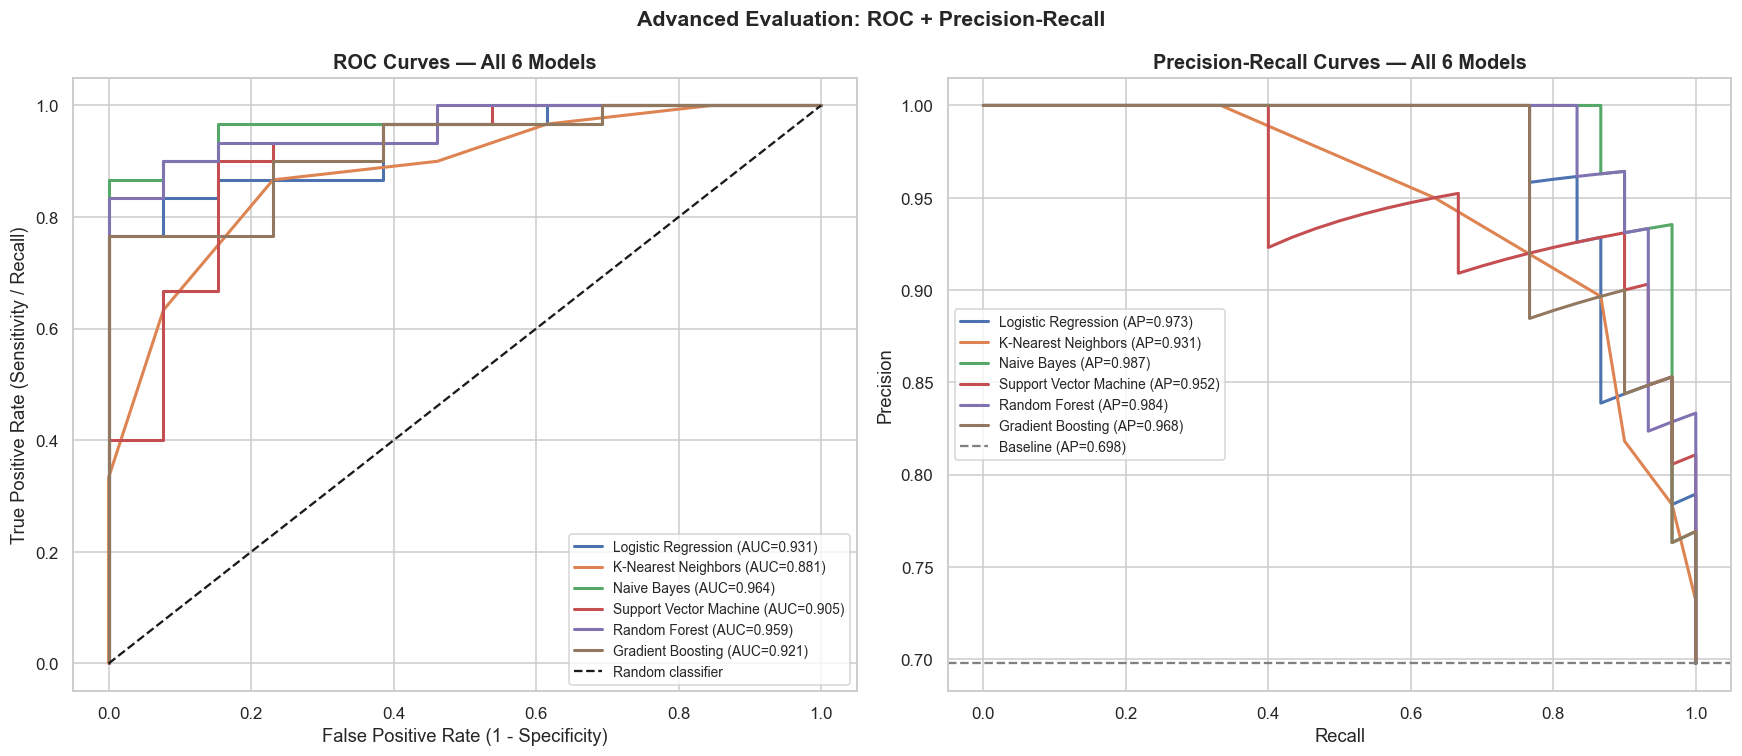

In [23]:
# 6.3 ROC Curves — All Models 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

palette = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

for result, color in zip(results, palette):
    fpr, tpr, _ = roc_curve(y_test, result['_te_prob'])
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f'{result["Model"]} (AUC={result["ROC-AUC"]:.3f})')

axes[0].plot([0,1],[0,1],'k--', lw=1.5, label='Random classifier')
axes[0].fill_between([0,1],[0,1],[0,1], alpha=0.05, color='grey')
axes[0].set_title('ROC Curves — All 6 Models', fontweight='bold', fontsize=13)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity / Recall)')
axes[0].legend(fontsize=9, loc='lower right')

# 6.4 Precision-Recall Curves 
for result, color in zip(results, palette):
    prec, rec, _ = precision_recall_curve(y_test, result['_te_prob'])
    ap = average_precision_score(y_test, result['_te_prob'])
    axes[1].plot(rec, prec, lw=2, color=color,
                 label=f'{result["Model"]} (AP={ap:.3f})')

baseline_recall = y_test.mean()
axes[1].axhline(baseline_recall, color='grey', linestyle='--', lw=1.5,
                label=f'Baseline (AP={baseline_recall:.3f})')
axes[1].set_title('Precision-Recall Curves — All 6 Models', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)

plt.suptitle('Advanced Evaluation: ROC + Precision-Recall', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## Section 7 - Handling Class Imbalance 

**Strategy 1 — class_weight='balanced':**
- Internally upweights the minority class during training
- The model sees misclassifying 'Not Placed' as more costly
- Zero computational overhead

**Strategy 2 — SMOTE (Synthetic Minority Over-sampling Technique):**
- Generates new synthetic 'Not Placed' samples in feature space
- Creates a balanced training set
- More powerful than simple oversampling (avoids exact duplicates)

In [24]:
# 7.1 Logistic Regression with class_weight='balanced' 
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_balanced.fit(x_train_scaled, y_train)
lr_bal_pred = lr_balanced.predict(x_test_scaled)
lr_bal_prob = lr_balanced.predict_proba(x_test_scaled)[:,1]

In [25]:
# 7.2 SMOTE 

if SMOTE_AVAILABLE:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_smote, y_smote = smote.fit_resample(x_train_scaled, y_train)
    print(f'Before SMOTE: {dict(pd.Series(y_train).value_counts())}')
    print(f'After  SMOTE: {dict(pd.Series(y_smote).value_counts())}')
    lr_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    lr_smote.fit(X_smote, y_smote)
    lr_smote_pred = lr_smote.predict(x_test_scaled)
    lr_smote_prob = lr_smote.predict_proba(x_test_scaled)[:,1]

Before SMOTE: {1: np.int64(118), 0: np.int64(54)}
After  SMOTE: {1: np.int64(118), 0: np.int64(118)}


── Imbalance Handling Comparison ──
                            Recall  Precision      F1     AUC
Approach                                                     
LR — Original               0.8333     0.9259  0.8772  0.9308
LR — class_weight=balanced  0.8000     0.9600  0.8727  0.9333
LR — SMOTE                  0.8333     0.9615  0.8929  0.9410


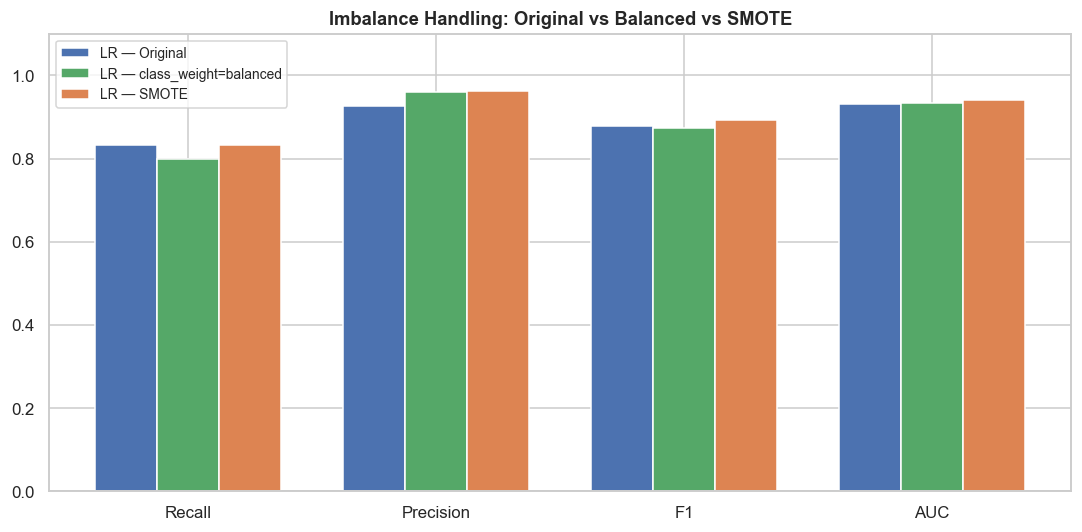

In [26]:
# 7.3 Compare: Original vs Balanced vs SMOTE

lr_orig = [r for r in results if r['Model']=='Logistic Regression'][0]

compare_rows = [
    {'Approach':'LR — Original',
     'Recall': recall_score(y_test, lr_orig['_te_pred']),
     'Precision': precision_score(y_test, lr_orig['_te_pred']),
     'F1': f1_score(y_test, lr_orig['_te_pred']),
     'AUC': roc_auc_score(y_test, lr_orig['_te_prob'])},
    {'Approach':'LR — class_weight=balanced',
     'Recall': recall_score(y_test, lr_bal_pred),
     'Precision': precision_score(y_test, lr_bal_pred),
     'F1': f1_score(y_test, lr_bal_pred),
     'AUC': roc_auc_score(y_test, lr_bal_prob)},
]

if SMOTE_AVAILABLE:
    compare_rows.append({
        'Approach':'LR — SMOTE',
        'Recall': recall_score(y_test, lr_smote_pred),
        'Precision': precision_score(y_test, lr_smote_pred),
        'F1': f1_score(y_test, lr_smote_pred),
        'AUC': roc_auc_score(y_test, lr_smote_prob)
    })

compare_df = pd.DataFrame(compare_rows).set_index('Approach').round(4)
print('── Imbalance Handling Comparison ──')
print(compare_df.to_string())

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(compare_df.columns))
w = 0.25
bar_colors = ['#4C72B0','#55A868','#DD8452']
for i, (approach, row) in enumerate(compare_df.iterrows()):
    ax.bar(x + i*w, row.values, w, label=approach,
           color=bar_colors[i], edgecolor='white')
ax.set_xticks(x + w); ax.set_xticklabels(compare_df.columns)
ax.set_title('Imbalance Handling: Original vs Balanced vs SMOTE', fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(0, 1.1)
plt.tight_layout(); plt.show()

## Section 8 - Hyperparameter Tuning with GridSearchCV

In [27]:
# 8.1 Logistic Regression Hyperparameter Tuning - C (Inverse of regularization strength)

lr_params = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
lr_gs = GridSearchCV(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                      lr_params, cv=5, scoring='f1', n_jobs=-1)
lr_gs.fit(x_train_scaled, y_train)
print(f'LR best C: {lr_gs.best_params_["C"]}  | Best CV F1: {lr_gs.best_score_:.4f}')

LR best C: 1  | Best CV F1: 0.9181


In [28]:
# 8.2 SVM Hyperparameter Tuning - C and gamma

svm_params = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1]}
svm_gs = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
                       svm_params, cv=5, scoring='f1', n_jobs=-1)
svm_gs.fit(x_train_scaled, y_train)
print(f'SVM best params: {svm_gs.best_params_}  | Best CV F1: {svm_gs.best_score_:.4f}')


SVM best params: {'C': 10, 'gamma': 0.01}  | Best CV F1: 0.9214


In [29]:
# 8.3 Random Forest 

rf_params = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20],
              'min_samples_leaf': [1, 2, 4]}
rf_gs = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                      rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_gs.fit(x_train_scaled, y_train)
print(f'RF best params: {rf_gs.best_params_}  | Best CV F1: {rf_gs.best_score_:.4f}')

RF best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}  | Best CV F1: 0.8939


In [30]:
# 8.4 Evalaute Tuned Models 

tuned = [
    ('LR (tuned)', lr_gs.best_estimator_),
    ('SVM (tuned)', svm_gs.best_estimator_),
    ('RF (tuned)', rf_gs.best_estimator_),
]
print('\n── Tuned Model Performance ──')
for name, m in tuned:
    pred = m.predict(x_test_scaled)
    prob = m.predict_proba(x_test_scaled)[:,1]
    print(f'{name:<18} Acc={accuracy_score(y_test,pred):.3f} F1={f1_score(y_test,pred):.3f} AUC={roc_auc_score(y_test,prob):.3f}')


── Tuned Model Performance ──
LR (tuned)         Acc=0.837 F1=0.877 AUC=0.931
SVM (tuned)        Acc=0.860 F1=0.897 AUC=0.905
RF (tuned)         Acc=0.837 F1=0.889 AUC=0.928
